In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

dc = pd.read_csv('/Users/rgao76/Documents/DiffTasks/overlap_2025/Data/all_data_LH.csv')
dc['Comparison_Type'] = dc.apply(
    lambda x: 'Between-subject same task' if x['Subject1'] != x['Subject2'] and x['Task1'] == x['Task2'] else \
            'Within-subject same task' if x['Subject1'] == x['Subject2'] and x['Task1'] == x['Task2'] else \
            'Within-subject different task' if x['Subject1'] == x['Subject2'] and x['Task1'] != x['Task2'] else \
            'Between-subject different task',
    axis=1
)
dc = dc[dc['Comparison_Type'] != 'Between-subject different task']
dc = dc[['Subject1', 'Subject2', 'Task1', 'Task2', 'Comparison_Type', 'DC']].groupby(['Subject1', 'Subject2', 'Task1', 'Task2', 'Comparison_Type']).mean().reset_index()
dc['Task1'] = dc['Task1'].replace({'V6': 'V4', 'V4': 'V5', 'V5': 'V6'})
dc['Task2'] = dc['Task2'].replace({'V6': 'V5', 'V4': 'V5', 'V5': 'V6'})

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

V2_Within-subject different task vs. V2_Within-subject same task: ***
V2_Between-subject same task vs. V2_Within-subject different task: ***
V3_Within-subject different task vs. V3_Within-subject same task: n.s.
V3_Between-subject same task vs. V3_Within-subject different task: ***
V5_Within-subject different task vs. V5_Within-subject same task: ***
V5_Between-subject same task vs. V5_Within-subject different task: ***
V6_Within-subject different task vs. V6_Within-subject same task: ***
V6_Between-subject same task vs. V6_Within-subject different task: ***
V4_Within-subject different task vs. V4_Within-subject same task: ***
V4_Between-subject same task vs. V4_Within-subject different task: ***
V1_Within-subject different task vs. V1_Within-subject same task: ***
V1_Between-subject same task vs.

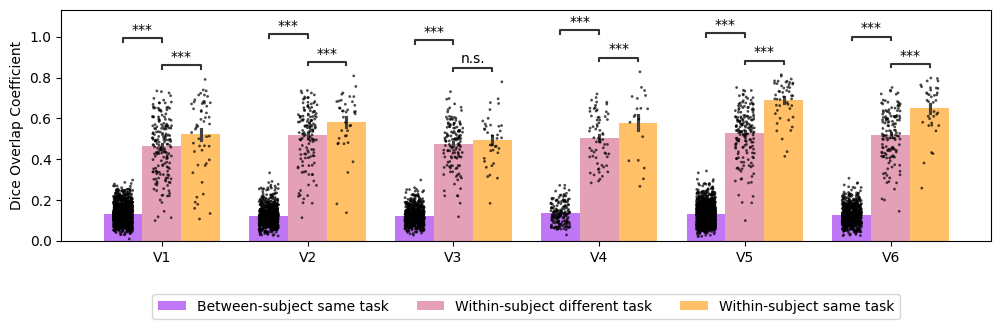

In [2]:
plt.figure(figsize=(12, 3))
ax = sns.barplot(
    x='Task1', 
    y='DC', 
    hue='Comparison_Type',
    data=dc, 
    saturation=1, 
    errorbar='se',
    hue_order=[
        'Between-subject same task', 
        'Within-subject different task', 
        'Within-subject same task'
    ],
    order=['V1', 'V2', 'V3', 'V4', 'V5', 'V6'],
    palette=['#bf77f6', '#e4a0b7', '#ffc067'],
)

sns.stripplot(
    x='Task1', 
    y='DC', 
    hue='Comparison_Type', 
    data=dc, 
    dodge=True,
    palette=['black', 'black', 'black'],
    alpha=0.7, 
    jitter=0.2, 
    size=2,
    hue_order=[
        'Between-subject same task', 
        'Within-subject different task', 
        'Within-subject same task'
    ],
    order=['V1', 'V2', 'V3', 'V4', 'V5', 'V6'],
    legend=False
)

# ---- Import annotation dataframe ----
annot_df = pd.read_csv("Tables/stats_LH_posthoc.csv")  
# parse the column "Regression Term" -> {Task1}:{Group1} vs {Task2}:{Group2}
annot_df['Task1'] = annot_df['Regression Term'].apply(lambda x: x.split(':')[0])
annot_df['Group1'] = annot_df['Regression Term'].apply(lambda x: x.split(' vs ')[0].split(':')[1])
annot_df['Task2'] = annot_df['Regression Term'].apply(lambda x: x.split(' vs ')[1].split(':')[0])
annot_df['Group2'] = annot_df['Regression Term'].apply(lambda x: x.split(' vs ')[1].split(':')[1])
annot_df['Task1'] = annot_df['Task1'].replace({'V6': 'V4', 'V4': 'V5', 'V5': 'V6'})
annot_df['Task2'] = annot_df['Task2'].replace({'V6': 'V4', 'V4': 'V5', 'V5': 'V6'})
# group Group1 and Group2, rename Within-subject.Same-task -> Within-subject same task, Within-subject.Different-task -> Within-subject different task, Between-subject.Same-task -> Between-subject same task
annot_df['Group1'] = annot_df['Group1'].replace({
    'Within-subject.Same-task': 'Within-subject same task',
    'Within-subject.Different-task': 'Within-subject different task',
    'Between-subject.Same-task': 'Between-subject same task'
})
annot_df['Group2'] = annot_df['Group2'].replace({
    'Within-subject.Same-task': 'Within-subject same task',
    'Within-subject.Different-task': 'Within-subject different task',  
    'Between-subject.Same-task': 'Between-subject same task'
})

pairs = []
custom_annotations = []
for _, row in annot_df.iterrows():
    task = row['Task1']
    group1 = row['Group1']
    group2 = row['Group2']
    label = row['pLabel']
    # replace nan to n.s.
    if pd.isna(label):
        label = 'n.s.'

    pairs.append(((task, group1), (task, group2)))
    custom_annotations.append(label)

annot = Annotator(
    ax, 
    pairs, 
    data=dc,
    x='Task1', 
    y='DC',
    hue='Comparison_Type',
    order=['V1', 'V2', 'V3', 'V4', 'V5', 'V6'],
    hue_order=[
        'Between-subject same task', 
        'Within-subject different task', 
        'Within-subject same task'
    ]
)

annot.set_custom_annotations(custom_annotations)
annot.annotate()

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.xlabel('')
plt.ylabel('Dice Overlap Coefficient')
plt.savefig('/Users/rgao76/Documents/DiffTasks/overlap_2025/Figures/overlap.png', 
            bbox_inches='tight', dpi=300, transparent=True)


In [3]:
# count the number of dots for each bar
dc.groupby(['Task1', 'Comparison_Type']).size().reset_index(name='Count')

,Task1,Comparison_Type,Count
0,V1,Between-subject same task,1326
1,V1,Within-subject different task,179
2,V1,Within-subject same task,52
3,V2,Between-subject same task,703
4,V2,Within-subject different task,135
5,V2,Within-subject same task,38
6,V3,Between-subject same task,666
7,V3,Within-subject different task,134
8,V3,Within-subject same task,37
9,V4,Between-subject same task,171
